## Reduced Gaussian grid - plotting methods

The reduced Gaussian grid (`reduced_gg`) is the native model grid used by
ECMWF's IFS.  Unlike a regular lat-lon grid, the number of points per
latitude circle decreases towards the poles, keeping the physical spacing
between grid points roughly constant across the globe.  The octahedral
variant (prefix `O`) is used by modern IFS versions.

This irregular point distribution means that naive plotting (e.g. reshaping
to a 2-D array) does not work without interpolation.  earthkit-plots handles
this transparently for all methods:

| Method | How it works | Best for |
|---|---|---|
| `grid_cells` | Draws each grid point as its Voronoi cell polygon | Seeing exact cell geometry |
| `point_cloud` | Plots a coloured marker at each grid point | Quick inspection |
| `contourf` | Interpolates to a regular grid then draws filled contours | Smooth maps |

This notebook uses an O32 reduced Gaussian 2-metre temperature field
(low resolution so the individual cells are clearly visible).

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source(
    "url",
    "https://get.ecmwf.int/repository/test-data/earthkit-regrid/test-data/global_0_360/O32.grib",
)

### Shared style

A single `Style` object keeps the colour scale consistent across all panels.

In [2]:
style = ekp.styles.Style(levels=range(10, 31), colors="Spectral_r", units="celsius")

### All methods side-by-side

We zoom to the Arctic where the reduced nature of the grid — fewer points
near the pole — is most obvious.

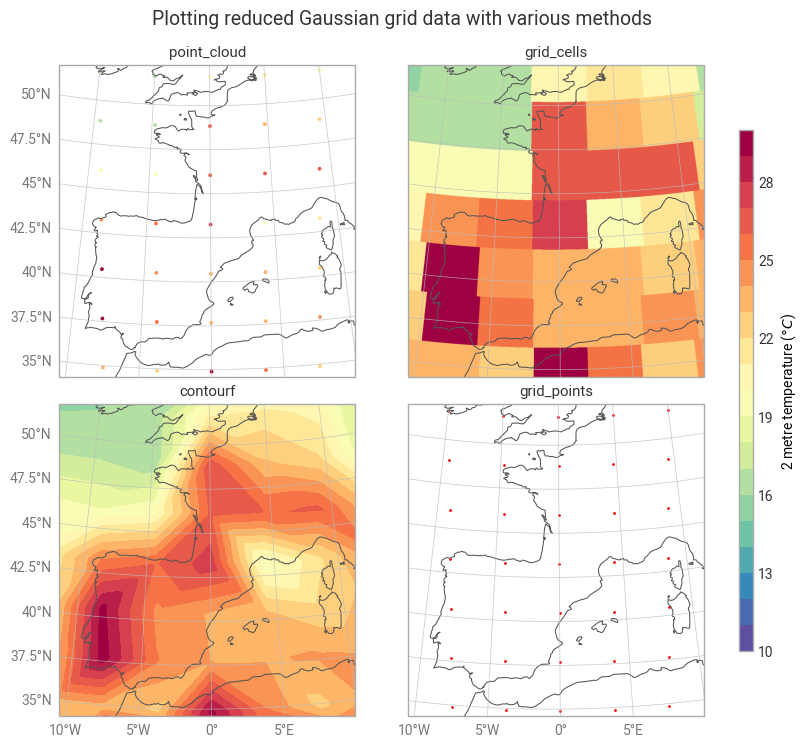

In [3]:
figure = ekp.Figure(rows=2, columns=2, domain=["France", "Spain"])

for method in ["point_cloud", "grid_cells", "contourf", "grid_points"]:
    subplot = figure.add_map()
    getattr(subplot, method)(data, style=style)
    subplot.title(method)

figure.coastlines()
figure.gridlines()

figure.title("Plotting reduced Gaussian grid data with various methods")

figure.legend(location="right")

figure.show()

### What to notice

- **`grid_cells`** reveals the variable cell width at different latitudes —
  wider cells near the equator, narrower (and fewer) cells near the poles.
  This is the defining characteristic of the reduced Gaussian grid.
- **`point_cloud`** makes the irregular point spacing clear: rows near the
  pole have noticeably fewer dots than rows near the equator.
- **`contourf`** hides the underlying grid structure entirely, presenting a
  smooth interpolated field.  This is often the right choice for final
  publication figures, but `grid_cells` is better for diagnosing data quality.